# Day 14 — Week 2 Wrap: COP Degradation in Indian Summer Heat
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**Note on this version:** the file that was on GitHub for Day 14 was actually broken — it was saved as a `.png`, but the file itself contained raw base64 text rather than real image bytes, so it couldn't render as a picture for anyone viewing the repository. This notebook rebuilds the analysis as a proper, executable notebook with the chart embedded directly, so the result is visible without needing a separate file at all.

**In plain terms:** Days 6–13 each looked at one design variable in isolation. This notebook pulls the thread through to its real-world conclusion: as **condensing temperature climbs through a typical Indian summer** (35°C up to a 55°C extreme), how much efficiency does each of the three refrigerant candidates actually lose? Two views: the **COP itself**, and the **% degradation relative to a mild 35°C baseline**.

**Evaporator fixed at -25°C** (ideal cycle, no superheat/subcooling) for a clean side-by-side comparison.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Reusable cycle function
def calculate_cycle(T_evap_C, T_cond_C, refrigerant="R600a"):
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15
    P_evap = CP.PropsSI("P","T",T_evap,"Q",1,refrigerant)
    P_cond = CP.PropsSI("P","T",T_cond,"Q",1,refrigerant)
    h1 = CP.PropsSI("H","T",T_evap,"Q",1,refrigerant)
    s1 = CP.PropsSI("S","T",T_evap,"Q",1,refrigerant)
    h2 = CP.PropsSI("H","P",P_cond,"S",s1,refrigerant)
    h3 = CP.PropsSI("H","T",T_cond,"Q",0,refrigerant)
    h4 = h3
    COP = (h1-h4)/(h2-h1)
    return COP

In [4]:
# CELL 4 — COP vs condensing temperature for R134a, R600a, R290
T_evap_C = -25
refrigerants = ["R134a", "R600a", "R290"]
T_cond_range = np.linspace(35, 55, 40)
colors = {"R134a": "#E53935", "R600a": "#2E7D32", "R290": "#1E88E5"}

cop_data = {}
for ref in refrigerants:
    cop_data[ref] = [calculate_cycle(T_evap_C, Tc, ref) for Tc in T_cond_range]

baseline = {ref: cop_data[ref][0] for ref in refrigerants}   # COP at 35C
degradation_pct = {ref: [(baseline[ref]-c)/baseline[ref]*100 for c in cop_data[ref]] for ref in refrigerants}

for ref in refrigerants:
    print(f"{ref}: COP at 35C = {cop_data[ref][0]:.3f}  |  COP at 55C = {cop_data[ref][-1]:.3f}  "
          f"|  degradation = {degradation_pct[ref][-1]:.1f}%")

R134a: COP at 35C = 3.044  |  COP at 55C = 1.877  |  degradation = 38.4%
R600a: COP at 35C = 3.098  |  COP at 55C = 1.935  |  degradation = 37.5%
R290: COP at 35C = 3.011  |  COP at 55C = 1.832  |  degradation = 39.1%


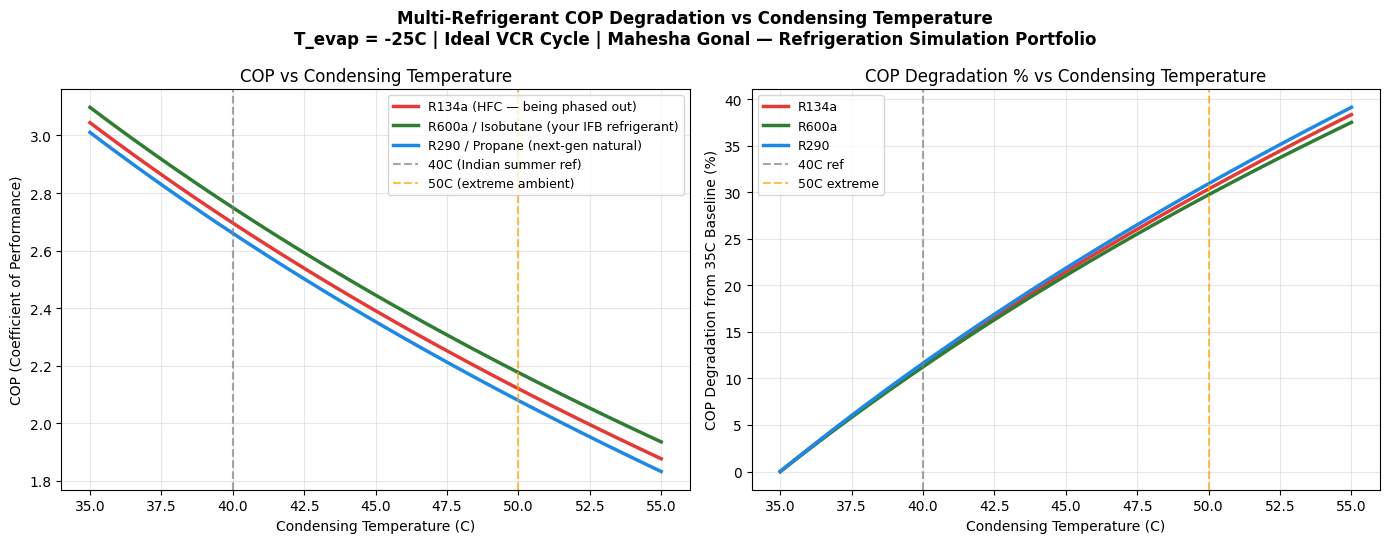

In [5]:
# CELL 5 — Two-panel chart: absolute COP, and % degradation from 35C baseline
fig, axes = plt.subplots(1, 2, figsize=(14,5.5))

labels = {"R134a": "R134a (HFC — being phased out)",
          "R600a": "R600a / Isobutane (your IFB refrigerant)",
          "R290": "R290 / Propane (next-gen natural)"}

for ref in refrigerants:
    axes[0].plot(T_cond_range, cop_data[ref], color=colors[ref], linewidth=2.5, label=labels[ref])
axes[0].axvline(40, color="gray", linestyle="--", alpha=0.7, label="40C (Indian summer ref)")
axes[0].axvline(50, color="orange", linestyle="--", alpha=0.7, label="50C (extreme ambient)")
axes[0].set_xlabel("Condensing Temperature (C)")
axes[0].set_ylabel("COP (Coefficient of Performance)")
axes[0].set_title("COP vs Condensing Temperature")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for ref in refrigerants:
    axes[1].plot(T_cond_range, degradation_pct[ref], color=colors[ref], linewidth=2.5, label=ref)
axes[1].axvline(40, color="gray", linestyle="--", alpha=0.7, label="40C ref")
axes[1].axvline(50, color="orange", linestyle="--", alpha=0.7, label="50C extreme")
axes[1].set_xlabel("Condensing Temperature (C)")
axes[1].set_ylabel("COP Degradation from 35C Baseline (%)")
axes[1].set_title("COP Degradation % vs Condensing Temperature")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle("Multi-Refrigerant COP Degradation vs Condensing Temperature\n"
             "T_evap = -25C | Ideal VCR Cycle | Mahesha Gonal — Refrigeration Simulation Portfolio",
             fontweight="bold")
plt.tight_layout()
plt.savefig("day14_cop_degradation_dashboard.png", dpi=150)
plt.show()

**What this chart tells us:** by the time condensing temperature reaches 50°C — not a rare event for a non-AC Indian kitchen in summer — every refrigerant has lost roughly **30% of the COP it had at a mild 35°C**. The three refrigerants stay close to each other throughout, which is the real takeaway: **switching away from R134a toward R600a or R290 doesn't trade away summer performance** — the regulatory-driven refrigerant transition (GWP/F-Gas) and the climate-driven efficiency problem are two separate issues, and solving one doesn't make the other worse.

This closes out Week 2: Days 8–13 built the individual design levers (cap tube, condenser, refrigerant choice, real-compressor losses), and this chart shows what all of them are ultimately fighting against — the Indian summer ambient itself.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day14_cop_degradation_dashboard.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Fix Day 14 - rebuild as notebook (was a broken base64-as-png file)", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Fix Day 14 - rebuild as notebook (was a broken base64-as-png file)", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
